# PyTorch Geometric, from zero to inductive LOS kriging

This notebook is your on-ramp to implementing the model described in `project.md` (Sections 3 and 5): a graph-attention network that does **inductive spatial interpolation** of InSAR line-of-sight displacement.

**How this notebook works.** You know general ML/DL but nothing about GNNs or PyTorch Geometric (PyG) yet. So this is built as a sequence of short concept notes followed by exercises — most code cells are deliberately **not filled in**. You'll see:

```python
# TODO ---------------------------------------------------------
# <what to build>
# Hints: <pointers to PyG docs / API names>
# Expected: <what you should see when it works>
# ----------------------------------------------------------------
```

Fill those in yourself, using the linked docs. A few cells (data loading, plotting) are given outright because they're plumbing, not the GNN skill you're here to build. Ask if you get stuck — there is no answer key hidden in this notebook on purpose.

**Reference docs you'll come back to repeatedly:**
- PyG "Introduction by Example": https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html
- PyG "Creating Message Passing Networks": https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html
- `GATv2Conv` API reference: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATv2Conv.html
- `DataLoader` / mini-batching: https://pytorch-geometric.readthedocs.io/en/latest/notes/batching.html

We build up in the same order the model gets more complex in `project.md`: toy graph → real spatial neighbourhood graph → one masked prediction → batched training → uncertainty → time series.

## 0. Setup

Given: environment sanity check. Run it and confirm no errors — if `torch_geometric` fails to import, the `uv` environment in this folder is broken and needs fixing before anything else matters.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)
print("cuda available:", torch.cuda.is_available())  # False is fine here, we're on a login node

/dss/dsshome1/0C/di54haf/LOSTInPLACE/tutorial/.venv/lib64/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


torch: 2.13.0+cu130
torch_geometric: 2.8.0.post1
cuda available: False


## 1. Graphs 101 — build one by hand

PyG represents a graph as a `Data` object with (at minimum):
- `x`: node feature matrix, shape `(num_nodes, num_node_features)`
- `edge_index`: which nodes are connected, shape `(2, num_edges)`, dtype `torch.long`, in **COO** format — `edge_index[:, i] = [src_i, dst_i]`
- `edge_attr` (optional): a feature vector per edge, shape `(num_edges, num_edge_features)`

**Before writing anything**, read the first part of the "Introduction by Example" page (link above) — it builds exactly this kind of toy graph and explains the COO/`edge_index` convention, including why an undirected edge needs **two** directed entries.

### Exercise 1
Invent 5 fictitious sensor locations: 4 outer points and 1 centre point. **`point5` (the centre) is the point you'll eventually want to interpolate** — for Exercises 1–3 that just means "the special node in the middle", nothing more; actual masking/prediction doesn't start until Exercise 6, so it's fine that its real displacement is visible in the graph for now. Give each point one scalar feature (a fake displacement value). Connect each outer node to the centre node, **and** to its 2 nearest neighbours among the other outer nodes, **undirected**. Build a PyG `Data` object with `x` and `edge_index`. Toy data can look something like this:
```
toy_data = {"point1": {"lat":1, "lon": 1, "disp": 5},
            "point2": {"lat":5, "lon": 1, "disp": 5},
            "point3": {"lat":1, "lon": 6, "disp": 5},
            "point4": {"lat":5, "lon": 6, "disp": 5},
            "point5": {"lat":3, "lon": 3, "disp": 5},
            }
```

Hints:
- With only 5 points, "nearest 2" can be worked out by eye/by hand or with `numpy` — you don't need `scipy` yet.
- Remember both directions per undirected edge.
- **`edge_index` and `edge_attr` are purely positional — nothing else links them.** Column `i` of `edge_index` (`[src_i, dst_i]`) and row `i` of a future `edge_attr` describe the *same* edge, only because they're at the *same index* `i`. There's no lookup by node name anywhere — whatever order you decide your edges are in when you build `edge_index`, any per-edge tensor you build later (Exercise 3) has to follow that exact same order. Good way to self-check: print `edge_index.t()` (one row per edge, as `(src, dst)`) and manually match a few rows against the node indices you assigned to `point1`...`point5` — do they point where you think they do?
- `x`'s row order defines what "node 0", "node 1", ... mean *everywhere else* (in `edge_index`, in any mask you build later) — so decide that ordering once (e.g. dict insertion order of `toy_data`) and stick to it.
- `data.validate(raise_on_error=True)` (a `Data` method) will tell you if something about your object is malformed — use it.
- `print(data)` gives you a compact shape summary.

In [4]:
# TODO ---------------------------------------------------------
# Turn the dict below into a PyG Data object: x (5, 1) ordered to match
# point1..point5, plus edge_index for the spokes+rim graph described above.
# (Name the Data object something other than `toy_data` - that name's
# already taken by your raw dict.)
# Expected: <your_data_object>.validate() passes; x=[5, 1],
#           edge_index=[2, E] with E = 2 * (4 spokes + however many rim
#           edges you drew between outer points).
# ----------------------------------------------------------------

toy_data = {"point1": {"lat":1, "lon": 1, "disp": 1.6, "index": 0},
            "point2": {"lat":5, "lon": 1, "disp": 3.7, "index": 1},
            "point3": {"lat":1, "lon": 6, "disp": 8.5, "index": 2},
            "point4": {"lat":5, "lon": 6, "disp": 9.1, "index": 3},
            "point5": {"lat":3, "lon": 3, "disp": 5.8, "index": 4},
            }

disp_values = torch.tensor([[toy_data["point1"]["disp"]], 
                            [toy_data["point1"]["disp"]], 
                            [toy_data["point1"]["disp"]],
                            [toy_data["point1"]["disp"]],
                            [toy_data["point1"]["disp"]]], 
                            dtype=torch.float)

# the nodes are in the order they are entered in the tensor. First entry is first node with index 0
edge_index = torch.tensor([[0,4,0,1,0,2,2,4,2,3,3,4,3,1,1,4 ],
                           [4,0,1,0,2,0,4,2,3,2,4,3,1,3,4,1 ]], dtype=torch.long)

# build the graph object
data = Data(x=disp_values, edge_index=edge_index)

data.validate(raise_on_error=True)
print(toy_data)

{'point1': {'lat': 1, 'lon': 1, 'disp': 1.6, 'index': 0}, 'point2': {'lat': 5, 'lon': 1, 'disp': 3.7, 'index': 1}, 'point3': {'lat': 1, 'lon': 6, 'disp': 8.5, 'index': 2}, 'point4': {'lat': 5, 'lon': 6, 'disp': 9.1, 'index': 3}, 'point5': {'lat': 3, 'lon': 3, 'disp': 5.8, 'index': 4}}


**Given:** a small plotting helper so you can visually sanity-check any graph you build in this notebook (this is not the skill you're here to learn, so it's handed to you).

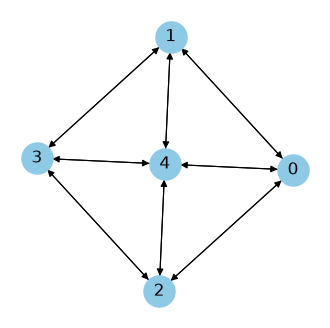

In [5]:
import networkx as nx

def plot_graph(data, pos=None, node_color=None, title=None):
    '''Draw a PyG Data object with networkx. `pos` is an optional {node_idx: (x, y)} dict.'''
    g = nx.DiGraph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    fig, ax = plt.subplots(figsize=(4, 4))
    nx.draw(g, pos=pos, ax=ax, with_labels=True, node_color=node_color or "#8ecae6",
            node_size=500, arrowsize=10, width=0.8)
    if title:
        ax.set_title(title)
    plt.show()

plot_graph(data)

## 2. Message passing, intuitively

Every GNN layer here follows the same three-step recipe:
1. **Message**: each edge computes a message from its source node's features (and its own edge features, if any).
2. **Aggregate**: each node collects the messages from all its incoming edges (sum / mean / attention-weighted).
3. **Update**: each node combines the aggregated message with its own previous features to get a new representation.

Concretely on your toy graph: after one `GATv2Conv` layer, `point5`'s (the centre's) output row is a learned combination of its neighbours' input features. It won't predict anything sensible yet (the layer is randomly initialised, untrained), but the information pathway your later interpolation model relies on is already there — this is worth noticing now.

`GATv2Conv` is a message-passing layer where step 2 is **attention-weighted**: it learns how much each neighbour should matter, instead of treating all neighbours equally (unlike a plain mean/sum). That matters for us — a neighbour 50 m away and highly coherent should plausibly matter more than one 2 km away, and attention lets the network learn that instead of us hand-coding it. `heads` gives you multiple independent attention patterns computed in parallel (like multi-head attention in a Transformer).

Read the `GATv2Conv` API reference (link above) — pay attention to: constructor args (`in_channels`, `out_channels`, `heads`, `concat`), what shape the output is, and the `return_attention_weights` option.

### Exercise 2
Instantiate a `GATv2Conv` (no edge features yet) and run it on `data.x` / `data.edge_index` — pass the two tensors **separately**, not the `Data` object. Ask for the attention weights as well, and inspect all three returned pieces.

Hints:
- `in_channels=-1` uses PyG's **lazy initialisation**: the layer infers the input width from the first batch it sees, so you don't have to hard-code it. Handy here; be aware it means shape errors surface on the first forward call rather than at construction.
- With `return_attention_weights=True` the layer returns a **tuple**, not a tensor: `out, (edge_index, alpha)`. Unpack it accordingly — `out.shape` on the raw tuple is an `AttributeError`.
- `alpha` holds one attention weight per edge per head. Untrained, the values are arbitrary — the point is seeing *where* they live and how they line up with `edge_index`.
- Output shape is `(5, heads * out_channels)` when `concat=True` (the default), because the heads are concatenated rather than averaged.

In [6]:
# TODO ---------------------------------------------------------
# 1. Instantiate a GATv2Conv mapping your toy node feature width -> some
#    output width, with heads=2.
# 2. Run it on data.x / data.edge_index (pass the two tensors separately -
#    not the Data object itself). Print the output shape
#    and explain to yourself why it has that shape (see `concat` in the docs).
# 3. Re-run with return_attention_weights=True and inspect what's returned.
# Expected: output shape is (5, heads * out_channels) by default.
# ----------------------------------------------------------------

from torch_geometric.nn import GATv2Conv

# create an instance of the Graph Attention convolution layer
conv = GATv2Conv(in_channels= -1, out_channels= 1,heads= 2, concat= True)       
# Feed the toydata into that graph
out, (ei, alpha) = conv(data.x, data.edge_index, return_attention_weights=True) 

print(ei)            # these are the edge indexes
print(alpha)         # These are the attention weights for the indexes (which connection should matter most or more than others?)
print(out)           # this is the output?
print(out.shape if out is not None else "not built yet")

# When return_attention_weights=True, GATv2Conv.forward doesn't return just the output tensor anymore; it returns a tuple: (out, (edge_index, alpha)), 
# where alpha is the attention weight per edge (per head) that the layer just computed. Your out variable is currently bound to that whole tuple, hence no .shape

tensor([[0, 4, 0, 1, 0, 2, 2, 4, 2, 3, 3, 4, 3, 1, 1, 4, 0, 1, 2, 3, 4],
        [4, 0, 1, 0, 2, 0, 4, 2, 3, 2, 4, 3, 1, 3, 4, 1, 0, 1, 2, 3, 4]])
tensor([[0.2000, 0.2000],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2000, 0.2000],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2000, 0.2000],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2000, 0.2000],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2500, 0.2500],
        [0.2000, 0.2000]], grad_fn=<DivBackward0>)
tensor([[-1.4153,  1.5688],
        [-1.4153,  1.5688],
        [-1.4153,  1.5688],
        [-1.4153,  1.5688],
        [-1.4153,  1.5688]], grad_fn=<AddBackward0>)
torch.Size([5, 2])


## 3. Edge features — why they matter here

`project.md` Section 3.3 makes a deliberate design choice: the model **never sees absolute coordinates**, only *relative* distance and direction, placed on edges. This is what makes the model translation-invariant (learns "how a neighbourhood configuration predicts its centre", not "region X behaves like Y").

This is also where "which edge is which" from Exercise 1 becomes concrete: you'll gather coordinates per edge using `edge_index`, so a mistake in that ordering now shows up as a wrong distance/direction number, not a crash.

`GATv2Conv(..., edge_dim=E)` lets a layer condition its attention/messages on an `edge_attr` of width `E`.

### Exercise 3
Using the coordinates already in your `toy_data` dict, compute for **every edge**:
- the distance between its two endpoints,
- the unit direction vector `(dx, dy) / distance`.

Stack these into an `(num_edges, 3)` `edge_attr` tensor, rebuild `data` to include it, and redo the forward pass with `GATv2Conv(..., edge_dim=3)`.

Why three columns, and why a *unit* vector: raw `(dx, dy)` tangles "how far" and "which way" into two correlated numbers. Splitting them hands the disentangling to the model for free — distance is a natural "how much should I trust this neighbour" signal, while direction carries anisotropy (a subsidence bowl doesn't look the same in every compass direction). A unit vector is also bounded in `[-1, 1]`, which behaves far better as a network input than an unbounded offset.

Hints:
- `edge_index[0]` = source nodes, `edge_index[1]` = destination nodes — use these to look up each edge's endpoints.
- Order matters: row `i` of `edge_attr` must describe the same edge as column `i` of `edge_index`. Build the two from the same loop/ordering rather than deriving each separately.
- Writing a small helper that takes two points and returns `(dist, u_x, u_y)` keeps the loop readable — just make sure you always pass **source first, destination second**, or the direction silently flips sign on some edges.
- This is the exact convention used later in `project.md` Section 5.6 — worth re-reading now.

In [7]:
# TODO ---------------------------------------------------------
# Build edge_attr (num_edges, 3) = [distance, unit_dx, unit_dy] and a new
# Data object toy_data_edges that includes it. Then run GATv2Conv(..., edge_dim=3).
# Expected: forward pass runs without shape errors.
# ----------------------------------------------------------------

import math

# short function to compute the distance between the points
def a(p1, p2):
    # takes a point from the toy_data dict and computes the necessar metrics.
    x1, y1 = p1["lon"], p1["lat"]
    x2, y2 = p2["lon"], p2["lat"]
    dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    u_x = (x2 - x1) / dist
    u_y = (y2 - y1) / dist

    return dist, u_x, u_y

# IMPORTANT: When using the function above source and target point selection must be consistent, otherwise the direction is wrong.

# This is here to look up all the edges and how they are connected
#edge_index = torch.tensor([[0,4,0,1,0,2,2,4,2,3,3,4,3,1,1,4 ],
#                           [4,0,1,0,2,0,4,2,3,2,4,3,1,3,4,1 ]], dtype=torch.long)

# the loop is a general way of filling the edge attribut tensor rather than hardcoding it.
edge_atts = []

for i in range(edge_index.shape[1]):
    source = toy_data["point" + str(edge_index[0, i].item() + 1)]
    target = toy_data["point" + str(edge_index[1, i].item() + 1)]

    edge_atts.append(a(source, target))

# Define edge features: For each edge, we want 3 dimensions (3 values) which stand for the distance etc...
edge_attr = torch.tensor(edge_atts, dtype=torch.float)

# rebuilding the data object
data = Data(x=disp_values, edge_index=edge_index, edge_attr=edge_attr)

# redoing the forward pass with the edge attributes
conv_e = GATv2Conv(in_channels= -1, out_channels= 1,heads= 2, edge_dim= 3, concat= True)       # <- replace
out, (ei, alpha) = conv_e(data.x, data.edge_index, edge_attr=edge_attr, return_attention_weights=True) 

print(out)
print(ei)
print(alpha)


tensor([[ 0.8101, -0.3625],
        [ 0.8101, -0.3625],
        [ 0.8101, -0.3625],
        [ 0.8101, -0.3625],
        [ 0.8101, -0.3625]], grad_fn=<AddBackward0>)
tensor([[0, 4, 0, 1, 0, 2, 2, 4, 2, 3, 3, 4, 3, 1, 1, 4, 0, 1, 2, 3, 4],
        [4, 0, 1, 0, 2, 0, 4, 2, 3, 2, 4, 3, 1, 3, 4, 1, 0, 1, 2, 3, 4]])
tensor([[0.1360, 0.3520],
        [0.1136, 0.4331],
        [0.2224, 0.2653],
        [0.1533, 0.2118],
        [0.3773, 0.1864],
        [0.5242, 0.1279],
        [0.3496, 0.1478],
        [0.1560, 0.3665],
        [0.3152, 0.2774],
        [0.2288, 0.2057],
        [0.2476, 0.1008],
        [0.1629, 0.3634],
        [0.4083, 0.0803],
        [0.2790, 0.1260],
        [0.0876, 0.2160],
        [0.1374, 0.4431],
        [0.2090, 0.2272],
        [0.2319, 0.2113],
        [0.2379, 0.2413],
        [0.2429, 0.2333],
        [0.1792, 0.1835]], grad_fn=<DivBackward0>)


## 4. Real data: an EGMS L2b sample

**Given** (plumbing, not the exercise): `data/egms_l2b_ascending_sample.csv` is a ~1km × 1km cutout (4772 points) taken from the real `EGMS_L2b_Ascending.zip` burst near Munich (`test_egms/egms_density_test/data/`), so you're working with real persistent-scatterer data from the start, not synthetic points.

Columns: `pid, mp_type, latitude, longitude, easting, northing, height_ortho, height_ellipse, line, pixel, rmse_ts, temporal_coherence, amplitude_dispersion, incidence_angle, track_angle, los_east, los_north, los_up, mean_velocity, mean_velocity_std, acceleration, acceleration_std, seasonality, seasonality_std, gnss_velocity`, followed by 208 date columns named like `20200104` (one LOS displacement value per acquisition, in mm, relative to the L2b reference).

(4772, 233) points x columns
208 acquisition dates: 20200104 to 20241226


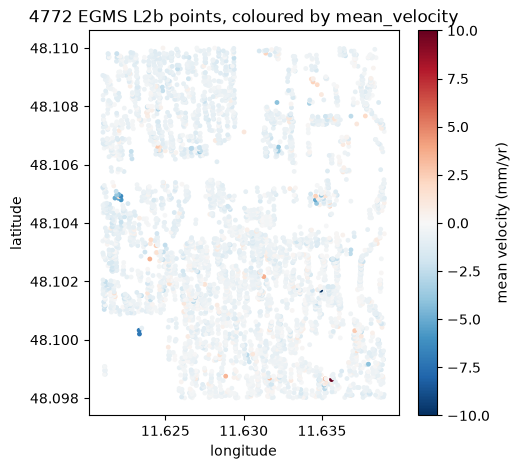

In [8]:
df = pd.read_csv("data/egms_l2b_ascending_sample.csv")
date_cols = [c for c in df.columns if c[:2] == "20"]
meta_cols = [c for c in df.columns if c not in date_cols]

print(df.shape, "points x columns")
print(len(date_cols), "acquisition dates:", date_cols[0], "to", date_cols[-1])

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(df.longitude, df.latitude, c=df.mean_velocity, cmap="RdBu_r", s=6, vmin=-10, vmax=10)
plt.colorbar(sc, label="mean velocity (mm/yr)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{len(df)} EGMS L2b points, coloured by mean_velocity")
plt.show()

## 5. Build one real k-NN query graph

Now do — on real data — exactly what `project.md` Section 5.6's `build_query_graph` sketches: pick one point as the **query/target**, find its `k` nearest neighbours, and build a star graph (all neighbours → target) with relative distance + direction as edge features.

Recall from our CRS discussion (`project.md` Section 10.7): the CRS itself doesn't matter, only that each pairwise distance/bearing is computed with something metrically valid. Easiest option here: `pyproj.Geod(ellps="WGS84").inv(lon1, lat1, lon2, lat2)` — it directly returns forward azimuth (degrees clockwise from north) and geodesic distance (metres) for arrays of points, no projection step needed. Convert azimuth → unit (dx, dy) via `sin`/`cos`.

### Exercise 5
Write `build_query_graph(df, target_idx, k)` that:
1. Computes distance + azimuth from row `target_idx` to every other row.
2. Takes the `k` nearest (excluding the target itself).
3. Builds node features for `1 + k` nodes: an `is_query` flag (1 for the query node, 0 for neighbours) plus one scalar — use `mean_velocity` for now, **zeroed out at the query node** (that's the mask: the model must never see the answer).
4. Builds `edge_index` (all neighbours → query, i.e. a directed star) and `edge_attr = [distance, unit_dx, unit_dy]`.
5. Stores the true value to predict as `data.y = df.mean_velocity.iloc[target_idx]` (a length-1 tensor).

Hints:
- `np.argpartition` or `np.argsort` for nearest-k.
- Double check you excluded the target from its own neighbour list (distance-to-self is 0 — don't let that sneak into `edge_attr`).
- `plot_graph` from Section 1 works on real data too if you build a `pos` dict from `data.x`/coordinates — handy for a sanity check on a couple of query graphs before trusting the function.

Index(['pid', 'mp_type', 'latitude', 'longitude', 'easting', 'northing',
       'height_ortho', 'height_ellipse', 'line', 'pixel',
       ...
       '20241003', '20241015', '20241027', '20241108', '20241120', '20241202',
       '20241214', '20241226', 'dist_m', 'forward_azimuth_deg'],
      dtype='str', length=235)
Data(x=[13, 2], edge_index=[2, 12], edge_attr=[12, 3], y=-0.5)


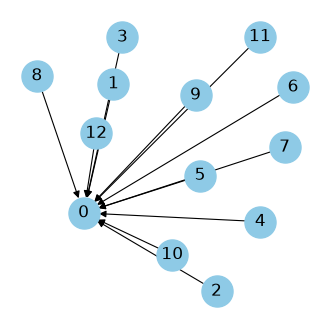

In [12]:
# TODO ---------------------------------------------------------
# Implement build_query_graph(df, target_idx, k) -> torch_geometric.data.Data
# Expected: for k=12, data.x.shape == (13, 2), data.edge_index.shape == (2, 12),
#           data.edge_attr.shape == (12, 3), data.y.shape == (1,)
# ----------------------------------------------------------------
print(df.columns)
from pyproj import Geod

def build_query_graph(df, target_idx, k=12):
    # First we extract the coords of the target point
    t_lat, t_lon = df.loc[target_idx, "latitude"], df.loc[target_idx, "longitude"]

    geod = Geod(ellps="WGS84")

    az12, az21, dist = geod.inv(
        df['longitude'].values.astype('float64'),  # lon1
        df['latitude'].values.astype('float64'),   # lat1   !!The dimensions of the target and all other points must match. so the target point has to be repeated n times to match the number of samples it is compared against
        np.full(len(df), t_lon),                   # lon2
        np.full(len(df), t_lat)                    # lat2
    )

    # az12: Forward azimuth from the DataFrame point to the target.
    # az21: Backward azimuth (from target to DF point).

    # add the new distance columns to the df
    df['dist_m'] = dist
    df['forward_azimuth_deg'] = az12
    
    # getting only the nearest
    k_nearest = df.nsmallest(k + 1, 'dist_m').iloc[1:]

    # tensors that I need:
    # x	of shape (1+k, 2)           Node features. Row 0 = query node, rows 1..k = neighbours. 
    #                               Col 0 = is_query flag (1.0 at row 0, 0.0 elsewhere). 
    #                               Col 1 = mean_velocity (real value for neighbour rows, zeroed at row 0 — that's the mask).
    # edge_index of shape (2, k)	One column per edge, directed neighbour → query (a star, not undirected this time — 
    #                               every neighbour points into the query, nothing points out of it). 
    #                               Row 0 = source indices (the k neighbour rows, i.e. 1..k). Row 1 = destination indices (always 0, the query).
    # edge_attr	of shape (k, 3)	    One row per edge, same order as edge_index's columns. Col 0 = distance (metres) from that neighbour to the query. 
    #                               Cols 1–2 = unit direction (dx, dy) from that neighbour to the query.
    # data.y of shape (1,)          The label: the query node's real mean_velocity — kept only here, deliberately never written into x.

    # Initialize a tensor with zeros only
    x = torch.zeros(k + 1, 2,  dtype=torch.float)
    # fill in the mean velocity values in the second column except the first row, the query row which stays zero.
    # Convert pandas Series to PyTorch tensor before assignment
    x[1:, 1] = torch.tensor(k_nearest["mean_velocity"].values, dtype=torch.float)
    # setting the query flag of the target point (row 1) to 1. All others in col1 remain 0.
    x[0, 0] = 1.0


    # Initialize the edge_indices
    edge_index = torch.zeros(2, k,  dtype=torch.long)
    # Row 0 = source indices (the k neighbour rows), Row 1 = destination indices (always 0, the query).
    # PyG's convention is edge_index[0] = src, edge_index[1] = dst
    edge_index[0,:] = torch.arange(1, k + 1)      # end of torch.arange is exclusive hence k+1


    # Initialize edge_attribute 
    edge_attr = torch.zeros(k, 3,  dtype=torch.float)
    # fill col 0 with distance
    edge_attr[:, 0] = torch.tensor(k_nearest['dist_m'].values, dtype= torch.float)
    # fill col 1 with unit direction dx
    edge_attr[:, 1] = torch.tensor(np.sin(np.radians(k_nearest['forward_azimuth_deg'].values)), dtype= torch.float)         
    # fill col 2 with unit direction dy
    edge_attr[:, 2] = torch.tensor(np.cos(np.radians(k_nearest['forward_azimuth_deg'].values)), dtype= torch.float) 

    # Building the Graph before adding the target value y
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

    # adding the y value
    data.y = torch.tensor(df.mean_velocity.iloc[target_idx], dtype = torch.float)

    return data
    
example_graph = build_query_graph(df, target_idx=0, k=12)
print(example_graph)
plot_graph(example_graph)

## 6. One training step — predicting a masked target

This is the core idea behind "query anywhere" (`project.md` Section 3.2): the network never sees the target's true value, only its neighbours plus relative geometry, and has to predict the centre.

### A quick primer: what "build a tiny model" actually means in PyTorch

Every custom model subclasses `torch.nn.Module` and has exactly two required parts:

1. **`__init__(self, ...)`**: call `super().__init__()` first (mandatory — PyTorch's parameter tracking depends on it), then create your layers as attributes (`self.something = nn.Linear(...)`, `self.conv1 = GATv2Conv(...)`, etc). Nothing gets *executed* here — you're only declaring which layers exist so PyTorch can track their weights.
2. **`forward(self, ...)`**: describes how input tensors actually flow through those layers, in order, to produce an output. This *is* the computation.

A minimal, non-graph example just to see the shape of the pattern — a 2-layer MLP mapping 4 input features to 1 output:

```python
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 8)
        self.layer2 = nn.Linear(8, 1)

    def forward(self, x):
        h = F.relu(self.layer1(x))
        return self.layer2(h)
```

Your `TinyGNN` follows exactly this shape — just with `GATv2Conv` instead of (or alongside) `nn.Linear`, and a graph (`data.x`, `data.edge_index`, `data.edge_attr`) instead of a plain tensor as input.

### Exercise 6, broken into steps

**1. `__init__`:** declare one `GATv2Conv` layer (reuse what you learned in Exercises 2–3 — remember `edge_dim=3`, since you have real edge features now), plus one `nn.Linear` mapping the conv's output width down to `1` (a single predicted scalar). Sizing: your node features (`x`) are width 2 going in. Pick a small hidden width for the conv's `out_channels` (e.g. 8) — and remember `heads` multiplies that width in the actual output unless you set `concat=False`. Whatever width comes out of the conv is what the following `Linear`'s `in_features` must equal.
*Optional, once the 1-layer version trains:* stack a second `GATv2Conv` before the `Linear`, with an activation (`F.gelu` or `F.relu`) between the two — the second conv's `in_channels` must match the first conv's actual output width.

**2. `forward(self, data)`:** run `data.x`, `data.edge_index`, `data.edge_attr` through your conv layer(s), then pick out **only the query node's row** from the result. Since Exercise 5 fixed the convention "query = index 0", and message passing never reorders nodes, that's simply row `0` of the conv's output for a single graph. (Once you batch many graphs together in Exercise 7, node 0 of *each* graph no longer lands at tensor-row 0 — that's when you'll need the boolean `is_query` mask instead, the same pattern from Exercises 1–3. For one single graph right now, plain row indexing is enough — don't over-build this yet.) Feed that one row through your `Linear` head to get the final scalar prediction.

**3. Loss + training loop:** this part is standard PyTorch, nothing graph-specific — it's a one-sample regression:
- Instantiate the model and `torch.optim.Adam(model.parameters(), lr=1e-2)`.
- Loop ~50–100 times: zero the gradients → forward pass on `example_graph` → compute `F.mse_loss(prediction, example_graph.y)` → `.backward()` → optimizer step.
- Print the loss periodically and confirm it trends down.

Hints:
- Shape-mismatch errors from `Linear` almost always mean this: the conv's *actual* output width (`out_channels * heads` if `concat=True`, else just `out_channels`) doesn't match the `in_features` you gave `Linear`. Print `h.shape` right after the conv call to check before wiring up the next layer.
- Your prediction and `example_graph.y` both need to be shape `(1,)` (or both plain scalars) for `F.mse_loss` — if it complains, check `pred.shape` vs `example_graph.y.shape` (and recall the shape fix `data.y` needed back in Exercise 5).

In [13]:
# TODO ---------------------------------------------------------
# Follow the 3 steps from the markdown above. Skeleton below with
# blanks marked <...> - fill them in, don't just delete them.
# Expected: printed loss decreases over the training loop.
# ----------------------------------------------------------------

class TinyGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels=2, out_channels=8, heads=2, edge_dim=3)
        # once the single-conv version trains end to end, try adding a second
        # conv layer here (remember: its in_channels must match conv1's actual
        # output width, and put an activation between the two conv calls below)
        self.head = torch.nn.Linear(in_features=16, out_features=1)

    def forward(self, data):
        h = self.conv1(data.x, data.edge_index, data.edge_attr)
        h_query = h[0]           # pick out the query node's row - see hint 2 above
        return self.head(h_query)

model = TinyGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for step in range(50):
    optimizer.zero_grad()
    pred = model(example_graph)                    # forward pass on example_graph
    loss = F.mse_loss(pred, example_graph.y)          # compare against example_graph.y
    loss.backward()
    optimizer.step()
    if step % 10 == 0:
        print(step, loss.item())

0 0.003912667743861675
10 0.0011559500126168132
20 0.00033832804183475673
30 0.0001326272904407233
40 4.11638175137341e-05


/dss/dsstbyfs02/scratch/0C/di54haf/di54haf/ipykernel_61862/4212853328.py:27: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(pred, example_graph.y)          # compare against example_graph.y


## 7. Many query graphs, batched

One masked point isn't training, it's memorising a single number. Real training needs many query graphs — different target points, each with its own neighbourhood.

PyG's `DataLoader` batches a *list* of variable-sized `Data` objects into one big disconnected graph (`edge_index` gets offset automatically per-graph) plus a `batch` vector saying which node belongs to which original graph. Read the batching note linked at the top before starting.

### The inductive-kriging trick (now core, not optional)

This is the mechanism from `project.md` Section 3.2 that makes "query anywhere" actually work: **before building each query graph, randomly drop ~20–30 % of the candidate neighbours**. The model then never sees the same neighbourhood layout twice, so it is forced to learn a transferable *function* of a local configuration rather than memorising fixed layouts.

Two consequences to design around:
- The surviving neighbour count varies per call, so **every tensor must be sized from the survivors**, not from `k`: `x`, `edge_index`, `edge_attr` and `query_mask` all change length together.
- The graphs must be **rebuilt every epoch**. A list built once and merely reshuffled by `DataLoader(shuffle=True)` gives you exactly one random layout per target, forever — the trick then does nothing. Shuffling changes *which graphs share a batch*; only rebuilding changes a graph's *contents*.

**Step vs. epoch:** one **step** = one batch = one optimizer update. One **epoch** = one pass over all training graphs = `ceil(n_graphs / batch_size)` steps. The redraw belongs at the top of the epoch loop.

### Exercise 7
1. Write `build_query_graph_indkrig(...)` — Exercise 5's builder plus the neighbour dropout, with all tensors sized from the surviving neighbour count.
2. Draw ~300 random target indices and split them into train / held-out (`sklearn.model_selection.train_test_split` is fine). Split the **indices**, not the graphs, since the training graphs get rebuilt each epoch.
3. Build the **held-out graphs once, outside the epoch loop**, so the evaluation task stays fixed and its loss is comparable between epochs. Only the training graphs are redrawn.
4. Attach a boolean `query_mask` to each `Data` object (`torch.zeros(n_nodes, dtype=torch.bool)`, `[0] = True`) so that after batching, `batch.query_mask` still selects exactly one row per graph. Then `h[data.query_mask]` in `forward` works unchanged for a single graph *or* a batch — replacing the `h[0]` from Exercise 6.
5. Write the training loop: for each epoch, rebuild the training graphs, wrap them in a fresh `DataLoader(..., batch_size=32, shuffle=True)`, iterate the batches, and track train + held-out loss per epoch.

Hints:
- Both the rebuild **and** the `DataLoader(...)` construction go inside the epoch loop — a loader wraps the list it was handed, so reusing an old loader keeps serving stale graphs.
- `model.train()` / `model.eval()` around the two phases, and `torch.no_grad()` for evaluation.
- Watch the reduction convention: if you accumulate `reduction="sum"` losses, divide by the total number of graphs; if you accumulate the default per-batch means, average those instead. Mixing the two silently rescales your curves.
- Sanity check: `h[batch.query_mask].shape[0]` should always equal `batch.num_graphs`.
- Don't expect impressive numbers. 4772 points in a 1 km box is a tiny, homogeneous world — this section is about the mechanics being right.

In [14]:
# TODO ---------------------------------------------------------
# Build the graph list, split train/held-out, wrap in DataLoader, and
# write the training loop. Reuse/extend TinyGNN from Section 6.
# Expected: training loss trends down over epochs; held-out loss is
#           noisier but should not be wildly worse (4700 points in a
#           1km box is a very small, homogeneous world - don't expect
#           much here, this is about the mechanics working).
# ----------------------------------------------------------------
from sklearn.model_selection import train_test_split

################################
# The build query graph function needs to be adjusted in order to incorporate the inductive kriging trick

def build_query_graph_indkrig(df, target_idx, k=25, mask_rate = 0.25):
    # First we extract the coords of the target point
    t_lat, t_lon = df.loc[target_idx, "latitude"], df.loc[target_idx, "longitude"]

    geod = Geod(ellps="WGS84")

    az12, az21, dist = geod.inv(
        df['longitude'].values.astype('float64'),  # lon1
        df['latitude'].values.astype('float64'),   # lat1   !!The dimensions of the target and all other points must match. so the target point has to be repeated n times to match the number of samples it is compared against
        np.full(len(df), t_lon),                   # lon2
        np.full(len(df), t_lat)                    # lat2
    )

    # az12: Forward azimuth from the DataFrame point to the target.
    # az21: Backward azimuth (from target to DF point).

    # add the new distance columns to the df
    df['dist_m'] = dist
    df['forward_azimuth_deg'] = az12
    
    # getting only the nearest
    k_nearest = df.nsmallest(k + 1, 'dist_m').iloc[1:]

    # Implementing the inductive kriging trick here: Every time the graph gets build, a random part of the nodes is left out so it is slightly different every time 
    ind_krig_mask = np.random.rand(len(k_nearest)) > mask_rate
    k_nearest = k_nearest[ind_krig_mask]
    # new variable to adapt to the changing length of k_nearest due to random draw
    n_k_nearest = len(k_nearest)

    # tensors that I need:
    # x	of shape (1+k, 2)           Node features. Row 0 = query node, rows 1..k = neighbours. 
    #                               Col 0 = is_query flag (1.0 at row 0, 0.0 elsewhere). 
    #                               Col 1 = mean_velocity (real value for neighbour rows, zeroed at row 0 — that's the mask).
    # edge_index of shape (2, k)	One column per edge, directed neighbour → query (a star, not undirected this time — 
    #                               every neighbour points into the query, nothing points out of it). 
    #                               Row 0 = source indices (the k neighbour rows, i.e. 1..k). Row 1 = destination indices (always 0, the query).
    # edge_attr	of shape (k, 3)	    One row per edge, same order as edge_index's columns. Col 0 = distance (metres) from that neighbour to the query. 
    #                               Cols 1–2 = unit direction (dx, dy) from that neighbour to the query.
    # data.y of shape (1,)          The label: the query node's real mean_velocity — kept only here, deliberately never written into x.

    # Initialize a tensor with zeros only
    x = torch.zeros(n_k_nearest + 1, 2,  dtype=torch.float)
    # fill in the mean velocity values in the second column except the first row, the query row which stays zero.
    # Convert pandas Series to PyTorch tensor before assignment
    x[1:, 1] = torch.tensor(k_nearest["mean_velocity"].values, dtype=torch.float)
    # setting the query flag of the target point (row 1) to 1. All others in col1 remain 0.
    x[0, 0] = 1.0

    # Initialize the edge_indices
    edge_index = torch.zeros(2, n_k_nearest,  dtype=torch.long)
    # Row 0 = source indices (the k neighbour rows), Row 1 = destination indices (always 0, the query).
    # PyG's convention is edge_index[0] = src, edge_index[1] = dst
    edge_index[0,:] = torch.arange(1, n_k_nearest + 1)      # end of torch.arange is exclusive hence k+1


    # Initialize edge_attribute 
    edge_attr = torch.zeros(n_k_nearest, 3,  dtype=torch.float)
    # fill col 0 with distance
    edge_attr[:, 0] = torch.tensor(k_nearest['dist_m'].values, dtype= torch.float)
    # fill col 1 with unit direction dx
    edge_attr[:, 1] = torch.tensor(np.sin(np.radians(k_nearest['forward_azimuth_deg'].values)), dtype= torch.float)         
    # fill col 2 with unit direction dy
    edge_attr[:, 2] = torch.tensor(np.cos(np.radians(k_nearest['forward_azimuth_deg'].values)), dtype= torch.float) 

    # Building the Graph before adding the target value y
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    # Initializing the query mask, so the target row can later be found again
    query_mask = torch.zeros(n_k_nearest+1, dtype=torch.bool)
    query_mask[0] = True
    data.query_mask = query_mask

    # adding the y value
    data.y = torch.tensor([df.mean_velocity.iloc[target_idx]], dtype=torch.float)

    return data

class TinyGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels=2, out_channels=8, heads=2, edge_dim=3)
        # once the single-conv version trains end to end, try adding a second
        # conv layer here (remember: its in_channels must match conv1's actual
        # output width, and put an activation between the two conv calls below)
        self.head = torch.nn.Linear(in_features=16, out_features=1)

    def forward(self, data):
        h = self.conv1(data.x, data.edge_index, data.edge_attr)
        h_query = h[data.query_mask]           # pick out the query node's row - see hint 2 above
        return self.head(h_query).squeeze(-1)
    
#####################################################################
#####################################################################
# Getting to the batching...

# generating random indices to draw 300 center nodes to build our 300 training examples from
np.random.seed(7)
random_indices = np.random.randint(0, len(df), size=300)

# train test split
train_indices, test_indices = train_test_split(random_indices, test_size=0.2, random_state=42)

# Creating an instance of the model defined above and the optimizer used here.
model = TinyGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

#######################################################################
# First building the test graphs outside of the epoch loop so are not randomized every epoch
g_test_list = []
for i in test_indices:
    g = build_query_graph_indkrig(df, i, k=25, mask_rate = 0.25)
    g_test_list.append(g)
# Loading the test graphs
loader_test = DataLoader(g_test_list, batch_size=64, shuffle=False)
#######################################################################

num_epochs = 50

# iterating over the epochs
for epoch in range(num_epochs):
    model.train()
    # For every epoch the graphs need to be remade from the same indices to incorporate the inductive kriging setup.
    g_train_list = []
    for i in train_indices:
         g = build_query_graph_indkrig(df, i, k=25, mask_rate=0.25) 
         g_train_list.append(g)
    loader_train = DataLoader(g_train_list, batch_size=32,shuffle=True)
    # Initializing the list to collect the per batch loss sum
    train_loss_batch = []
    # Now iterating over the batches to conduct training
    for batch in loader_train:
        optimizer.zero_grad()
        pred = model(batch)
        loss = F.mse_loss(pred, batch.y, reduction="sum")
        train_loss_batch.append(loss.item())
        loss.backward()
        optimizer.step()

    # Computing the train loss per epoch 
    train_loss_batch_sum = sum(train_loss_batch) / len(g_train_list)

    ###########################################
    # Now the eval block per epoch

    model.eval()
    with torch.no_grad():
        test_loss_batch = []
        for batch in loader_test:
            pred = model(batch)
            loss = F.mse_loss(pred, batch.y, reduction='sum')
            test_loss_batch.append(loss.item())
    test_loss_batch_sum = sum(test_loss_batch) / len(g_test_list)

    ##########################################
    # Printing the loss per epoch:

    if epoch % 10 ==0:
        print("#=====================================#")
        print(f"# Train Loss in Epoch {epoch}: {np.round(train_loss_batch_sum, 3)}#")
        print(f"# Test Loss in Epoch {epoch}: {np.round(test_loss_batch_sum,3)}#")
        print("#=====================================#")

    if epoch == num_epochs:
        print("#=====================================#")
        print(f"# Final Train Loss in Epoch {epoch}: {np.round(train_loss_batch_sum, 3)}#")
        print(f"# Final Test Loss in Epoch {epoch}: {np.round(test_loss_batch_sum, 3)}#")
        print("#=====================================#")


#=====================================#
# Train Loss in Epoch 0: 0.401#
# Test Loss in Epoch 0: 0.998#
#=====================================#
#=====================================#
# Train Loss in Epoch 10: 0.324#
# Test Loss in Epoch 10: 1.122#
#=====================================#
#=====================================#
# Train Loss in Epoch 20: 0.295#
# Test Loss in Epoch 20: 1.291#
#=====================================#
#=====================================#
# Train Loss in Epoch 30: 0.308#
# Test Loss in Epoch 30: 0.427#
#=====================================#
#=====================================#
# Train Loss in Epoch 40: 0.308#
# Test Loss in Epoch 40: 0.397#
#=====================================#


## 8. Aleatoric uncertainty: predicting a variance too

`project.md` Section 6.1: instead of a single number, the network predicts a mean **and** a log-variance per target, trained with Gaussian negative log-likelihood (`F.gaussian_nll_loss`) instead of MSE. This is the "how sure am I" signal.

### Exercise 8
Give the model a **second linear head** alongside `mu` (same input width), so `forward` returns `(mu, logvar)` instead of one tensor. Clamp `logvar` to roughly `[-8, 8]` before exponentiating — unclamped log-variance heads are a classic source of training blow-ups, and `project.md` 5.5 does the same. Then retrain on the Section 7 batched setup and inspect the predicted spread against the truth on the held-out split.

Hints:
- **`forward` now returns a tuple**, so the caller must unpack it: `mu, logvar = model(batch)`. Keeping `pred = model(batch)` binds the whole tuple and every downstream use fails.
- The loss wants the **variance**, not the log-variance: `F.gaussian_nll_loss(mu, batch.y, logvar.exp())`. The clamp is what keeps that `exp` inside a sane range (~`3e-4` to `3e3`).
- `.squeeze(-1)` both heads so `mu`, `var` and `batch.y` are all `(N,)`. A `(N,1)` prediction against a `(N,)` target broadcasts to an `(N,N)` outer difference — it runs, warns, and silently trains the model toward the *batch mean* instead of each graph's own label.
- `gaussian_nll_loss` defaults to `reduction='mean'`, unlike the `reduction="sum"` you may have used for MSE. Keep the per-epoch averaging consistent with whichever you pick.
- NLL is not comparable to MSE — it is a likelihood and can go negative. If you want both a calibration signal and an interpretable error, track NLL *and* MSE-on-`mu` separately rather than swapping one for the other.
- Printing `batch.y`, `mu` and `sqrt(var)` side by side for a few graphs is a quick way to see whether the spread is sane. A scatter of `mu ± sqrt(var)` against truth over the whole held-out set is the better diagnostic once the numbers look plausible.

In [ ]:
# TODO ---------------------------------------------------------
# Add a logvar head, switch the loss, retrain, and plot predicted
# intervals vs. truth on the held-out split.
# ----------------------------------------------------------------

# First the model definition has to be updated to incorporate a second linear head
# A little trick has to be applied to avoid logvar becoming inf or 0
# Both are returned and the actual learning of the variance happens due to a different loss function in the training process.

class TinyGNN_head(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels=2, out_channels=8, heads=2, edge_dim=3)
        # once the single-conv version trains end to end, try adding a second
        # conv layer here (remember: its in_channels must match conv1's actual
        # output width, and put an activation between the two conv calls below)
        self.mu_head = torch.nn.Linear(in_features=16, out_features=1)
        self.logvar_head = torch.nn.Linear(in_features=16, out_features=1)

    def forward(self, data):
        h = self.conv1(data.x, data.edge_index, data.edge_attr)
        h_query = h[data.query_mask]           # pick out the query node's row - see hint 2 above
        mu = self.mu_head(h_query).squeeze(-1)
        logvar = self.logvar_head(h_query).squeeze(-1)
        logvar = torch.clamp(logvar, min=-8, max=8)        # This is the step the prevents logvar from becoming 0 or inf
        return mu, logvar

######################################################
# Updated training including the new Loss function

# generating random indices to draw 300 center nodes to build our 300 training examples from
np.random.seed(7)
random_indices = np.random.randint(0, len(df), size=300)

# train test split
train_indices, test_indices = train_test_split(random_indices, test_size=0.2, random_state=42)

# Creating an instance of the model defined above and the optimizer used here.
model = TinyGNN_head()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

#######################################################################
# First building the test graphs outside of the epoch loop so are not randomized every epoch
g_test_list = []
for i in test_indices:
    g = build_query_graph_indkrig(df, i, k=25, mask_rate = 0.25)
    g_test_list.append(g)
# Loading the test graphs
loader_test = DataLoader(g_test_list, batch_size=64, shuffle=False)
#######################################################################

num_epochs = 50

# iterating over the epochs
for epoch in range(num_epochs):
    # Later the model is set to eval mode so it needs to be reset to training mode 
    # at the beginning of every epoch
    model.train()
    # For every epoch the graphs need to be remade from the same indices to incorporate the inductive kriging setup.
    g_train_list = []
    for i in train_indices:
         g = build_query_graph_indkrig(df, i, k=25, mask_rate=0.25) 
         g_train_list.append(g)
    loader_train = DataLoader(g_train_list, batch_size=32,shuffle=True)
    # Initializing the list to collect the per batch loss sum
    train_loss_batch = []
    # Now iterating over the batches to conduct training
    for batch in loader_train:
        optimizer.zero_grad()
        mu, logvar = model(batch)                        # Previously the model output only the prediction, hence only pred was assigned from model. Now mu and logvar need to be assigned
        loss = F.gaussian_nll_loss(mu, batch.y, logvar.exp())     # std = torch.exp(0.5 * logvar)
        #F.mse_loss(pred, batch.y, reduction="sum")  
        train_loss_batch.append(loss.item())
        loss.backward()
        optimizer.step()

    # Computing the train loss per epoch 
    train_loss_batch_sum = sum(train_loss_batch) / len(g_train_list)

    ###########################################
    # Now the eval block per epoch

    model.eval()
    with torch.no_grad():
        test_loss_batch = []
        for batch in loader_test:
            mu, logvar = model(batch)
            loss = F.gaussian_nll_loss(mu, batch.y, logvar.exp())
            test_loss_batch.append(loss.item())

            # Printing this per batch in the eval block is not ideal but enough for now to get a feeling for the results.
            print( f"Ground Truth: {batch.y[:8]}")
            print(f"Prediction: {mu[:8]}")
            print(f"Standard Deviation: {np.sqrt(logvar.exp()[:8])}")

    test_loss_batch_sum = sum(test_loss_batch) / len(g_test_list)

    ##########################################
    # Printing the loss per epoch:

    if epoch % 10 ==0:
        print("#=====================================#")
        print(f"# Train Loss in Epoch {epoch}: {np.round(train_loss_batch_sum, 3)}#")
        print(f"# Test Loss in Epoch {epoch}: {np.round(test_loss_batch_sum,3)}#")
        print("#=====================================#")

    if epoch == num_epochs:
        print("#=====================================#")
        print(f"# Final Train Loss in Epoch {epoch}: {np.round(train_loss_batch_sum, 3)}#")
        print(f"# Final Test Loss in Epoch {epoch}: {np.round(test_loss_batch_sum, 3)}#")
        print("#=====================================#")

Ground Truth: tensor([-0.8000, -0.4000,  0.9000, -1.5000, -0.3000,  0.0000, -0.5000, -1.9000])
Prediction: tensor([-0.6308, -0.6317, -0.4692, -0.7263, -0.5545, -0.6283, -0.5806, -0.7737])
Standard Deviation: tensor([0.8513, 0.8491, 0.8420, 0.8638, 0.8433, 0.8505, 0.8480, 0.8640])
#=====================================#
# Train Loss in Epoch 0: 0.009#
# Test Loss in Epoch 0: 0.002#
#=====================================#


/dss/dsstbyfs02/scratch/0C/di54haf/di54haf/ipykernel_117010/1399365076.py:93: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"Standard Deviation: {np.sqrt(logvar.exp()[:8])}")


Ground Truth: tensor([-0.8000, -0.4000,  0.9000, -1.5000, -0.3000,  0.0000, -0.5000, -1.9000])
Prediction: tensor([-0.6036, -0.6048, -0.4322, -0.6972, -0.5242, -0.5998, -0.5491, -0.7491])
Standard Deviation: tensor([0.6019, 0.6003, 0.6085, 0.6026, 0.6026, 0.6015, 0.6037, 0.5989])
Ground Truth: tensor([-0.8000, -0.4000,  0.9000, -1.5000, -0.3000,  0.0000, -0.5000, -1.9000])
Prediction: tensor([-0.4901, -0.4916, -0.2601, -0.5999, -0.3867, -0.4825, -0.4149, -0.6735])
Standard Deviation: tensor([0.5172, 0.5158, 0.5205, 0.5191, 0.5165, 0.5166, 0.5180, 0.5162])
Ground Truth: tensor([-0.8000, -0.4000,  0.9000, -1.5000, -0.3000,  0.0000, -0.5000, -1.9000])
Prediction: tensor([-0.6134, -0.6152, -0.3764, -0.7119, -0.5123, -0.6050, -0.5353, -0.7958])
Standard Deviation: tensor([0.5601, 0.5585, 0.5249, 0.5860, 0.5400, 0.5582, 0.5482, 0.5941])
Ground Truth: tensor([-0.8000, -0.4000,  0.9000, -1.5000, -0.3000,  0.0000, -0.5000, -1.9000])
Prediction: tensor([-0.5053, -0.5061, -0.2952, -0.5794, -0.420

KeyboardInterrupt: 

## 9. From one scalar to a whole time series

So far every exercise used a single scalar (`mean_velocity`) as the prediction target, to keep the graph mechanics simple. The real target is the full LOS time series. Feeding the raw ~200-length series as a node feature technically works in PyG (feature width is just a number to it), but it forces every point onto a shared fixed-length grid, breaks continuous-time querying, and gives you no mechanism for gaps or short records elsewhere in the world. `project.md` Section 3.5 instead fits each series to a small **temporal basis** and works in coefficient space.

**Basis fit vs. polynomial fit.** Both are linear least squares — `y ≈ Φ c`, solved with `lstsq`. The only thing that differs is what the columns of `Φ` are, and that choice decides what the model *can* represent:

| | polynomial (`np.polyfit`) | basis fit (§3.5) |
|---|---|---|
| columns of `Φ` | `1, t, t², t³, …` | `1, t`, then `sin/cos(2πht/365.25)` |
| seasonality | cannot represent a repeating annual cycle — a cubic bends at most twice over the record | explicit, one harmonic pair per cycle |
| extrapolation | diverges rapidly outside the fitted range | trend stays linear, seasonal part stays bounded |
| conditioning | raw powers are strongly correlated (intercept/trend correlate at −0.82 here) | still correlated as-is, but the columns are meaningful and can be orthonormalised |
| time axis | often fitted against acquisition *index* | must be real elapsed **days** |

Two consequences matter for this project specifically:
- **Real elapsed days, not index.** This record switches from 6-day to 12-day sampling, and ascending/descending orbits acquire on *different* dates. Index-based coefficients therefore don't live in a shared basis across orbits, which would break the decomposition entirely.
- **Orthonormalise the basis (QR).** Correlated coefficients mean the per-coefficient variance head from Exercise 8 is wrong: propagating only the diagonal through `Var[LOS(t)] = Φ Σ Φᵀ` overestimates σ by up to 76 % with a raw basis. After `np.linalg.qr`, the coefficients are uncorrelated and the diagonal head is exact.

Because both reconstruction (`Φ @ c`) and the eventual decomposition are **linear**, the mean and the variance pass through unchanged — and you can even do the LOS→EW/Up inversion directly on the coefficients and reconstruct once at the end, instead of reconstructing both orbits first.

### Exercise 9a — fit and reconstruct
Build a design matrix `Φ` of shape `(T, p)` from the acquisition dates (constant, linear trend, and one annual `sin`/`cos` pair → `p = 4`), solve for one point's coefficients with `np.linalg.lstsq`, reconstruct `Φ @ c`, and plot it over the raw series.

Hints:
- `pd.to_datetime(col, format="%Y%m%d")`, then subtract the first date and take `.days`.
- Write it with a validity mask (`~np.isnan`) filtering both `Φ` and `y`, even though this sample has no gaps — real and non-EGMS series won't be this clean (`project.md` Section 10.8).
- On a noise-dominated point the residual will barely improve on the raw standard deviation. That's expected, not a bug — `p = 4` is deliberately low-capacity, and this patch is nearly flat.

### Exercise 9b — generalise the builder
Rewrite the query-graph builder so the node features are each point's `p` coefficients instead of one scalar, and `y` is the target's coefficient vector. Make the feature widths **derived rather than hard-coded**, so changing the basis (or adding an edge column) propagates automatically.

Hints:
- Node width is `1 + p` (query flag + coefficients); edge width is however many columns you stack. Derive both instead of passing `n_nodefeatures` / `n_predictfeatures` separately — two parameters bound by an unenforced relation is a bug waiting to happen.
- Fit the coefficients **inside** the builder, after neighbour selection, so only the target + surviving neighbours are fitted rather than all 4772 points. `lstsq` takes a matrix right-hand side, so one call solves them all.
- `y` must be shape `(1, p)`, not `(p,)`: PyG concatenates along dim 0, so `(p,)` collates to `(N*p,)` — flattened and unusable against an `(N, p)` prediction.
- Build `Φ` **once** outside the builder and pass it in; it depends only on the acquisition dates, which every point in a burst shares.

Still open after this section: giving the model `p`-dimensional `mu`/`logvar` heads and retraining on coefficient targets.

n_harmonics=1: p=4  x=(20, 5)  edge_attr=(19, 3)  y=(1, 4)
n_harmonics=2: p=6  x=(20, 7)  edge_attr=(19, 3)  y=(1, 6)
n_harmonics=3: p=8  x=(20, 9)  edge_attr=(19, 3)  y=(1, 8)

batched  x=(149, 5)  y=(8, 4)  query rows selected=(8, 5)
query coefficients masked to zero: True
node counts, same target rebuilt 6x: [19, 20, 20, 19, 21, 20]


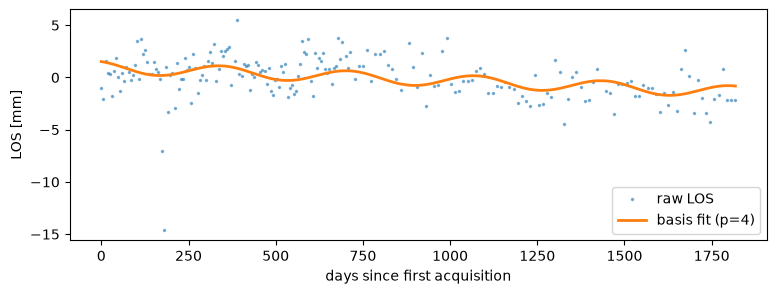

residual std 1.92 mm vs raw series std 2.08 mm


In [24]:
# =============================================================================
# Exercise 9b - generalised query-graph builder
# =============================================================================
# CHANGES vs. the Exercise 7 version, and why:
#
#  1. FEATURE WIDTHS ARE NOW DERIVED, NOT PASSED.
#     Removed n_nodefeatures / n_predictfeatures / n_edgeattributes. They were
#     three parameters that had to satisfy a hidden relation
#     (n_nodefeatures == n_predictfeatures + 1) with nothing enforcing it.
#     Node width is now 1 + p (flag + coefficients) where p = Phi.shape[1];
#     edge width is len(the list of edge columns). Change the basis or add an
#     edge column and every shape follows automatically.
#
#  2. COEFFICIENTS ARE FITTED INSIDE THE FUNCTION, AFTER NEIGHBOUR SELECTION.
#     Only the target + surviving neighbours (~26 series) are fitted per call
#     instead of pre-fitting all 4772. One lstsq call solves them together
#     (lstsq accepts a matrix right-hand side), so it is also faster than the
#     previous per-row loop.
#
#  3. REPLACED np.polyfit WITH THE PROJECT.MD 3.5 BASIS.
#     - time is real elapsed DAYS, not acquisition index (this record switches
#       from 6-day to 12-day sampling, and asc/desc have different dates - an
#       index-based basis is not shared between orbits, which would break the
#       coefficient-space decomposition).
#     - constant + linear trend + n_harmonics annual harmonics, so seasonality
#       is representable (a cubic cannot represent an annual cycle).
#     - columns orthonormalised via QR, so the coefficients are uncorrelated
#       and the diagonal variance head of Exercise 8 is exact rather than an
#       approximation (a raw polynomial basis correlates intercept/trend at
#       -0.82, which inflates reconstructed sigma by up to 76%).
#
#  4. data.y IS NOW THE TARGET'S COEFFICIENT VECTOR, SHAPE (1, p).
#     Was mean_velocity (which no longer exists once the frame is reduced).
#     The (1, p) shape matters: PyG concatenates along dim 0, so a (p,) y
#     collates to (N*p,) - flattened and unusable - while (1, p) gives (N, p).
#
#  5. NO MORE MUTATION OF THE CALLER'S DataFrame.
#     The old version wrote df['dist_m'] / df['forward_azimuth_deg'] on every
#     call. Distances/azimuths are kept as local arrays now.
#
#  6. SELF-EXCLUSION IS EXPLICIT: order[order != target_idx] instead of
#     nsmallest(k+1).iloc[1:], which silently assumed the target is always the
#     single closest row (untrue if two points share coordinates).
#
#  7. Indexing is positional (.iloc / numpy) throughout, so target_idx means
#     "row number" consistently - the old code mixed .loc and .iloc.
#
# UNCHANGED: the star topology (neighbours -> query), the edge features
# [distance, sin(az), cos(az)] from the forward azimuth, the is_query flag in
# column 0, the query_mask, and the inductive-kriging neighbour dropout.
# =============================================================================

import re
from pyproj import Geod

_GEOD = Geod(ellps="WGS84")


def temporal_basis(date_cols, n_harmonics=1, orthonormalise=True):
    """Design matrix Phi of shape (T, p) for the project.md 3.5 temporal basis.

    Build this ONCE per dataset and pass it in - it depends only on the
    acquisition dates, which every point in a burst shares.

    p = 2 + 2 * n_harmonics   (constant, linear trend, then sin/cos per harmonic)
    """
    dates = pd.to_datetime(pd.Index(date_cols), format="%Y%m%d")
    t = (dates - dates[0]).days.to_numpy(float)          # real elapsed days
    cols = [np.ones_like(t), t / 365.25]
    for h in range(1, n_harmonics + 1):
        w = 2 * np.pi * h / 365.25
        cols += [np.sin(w * t), np.cos(w * t)]
    Phi = np.stack(cols, axis=1)
    if orthonormalise:
        Phi, _ = np.linalg.qr(Phi)                       # uncorrelated coefficients
    return Phi


def build_query_graph_indkrig(df, target_idx, date_cols, Phi, k=25, mask_rate=0.25,
                              lat_col="latitude", lon_col="longitude"):
    """One masked query graph: neighbours -> query star, coefficients as features.

    df         : frame with lat/lon columns and one column per acquisition date
    target_idx : POSITIONAL row index of the query point
    date_cols  : the acquisition-date column names, in chronological order
    Phi        : (T, p) design matrix from temporal_basis()
    k          : candidate neighbours before dropout
    mask_rate  : fraction of candidates dropped each call (inductive kriging)

    Returns a Data object with
        x          (1 + n_nbr, 1 + p)  col 0 = is_query flag, cols 1: = coefficients
                                       (query row's coefficients zeroed = masked)
        edge_index (2, n_nbr)          row 0 = neighbour, row 1 = query
        edge_attr  (n_nbr, 3)          [distance_m, unit_dx, unit_dy]
        query_mask (1 + n_nbr,)        True at the query row only
        y          (1, p)              the query's TRUE coefficients

    NOTE: assumes the series contain no NaNs (true for EGMS). Gappy series
    would need a per-point validity mask, which cannot use one shared lstsq.
    """
    lat = df[lat_col].to_numpy(float)
    lon = df[lon_col].to_numpy(float)
    n = len(df)

    # geodesic distance + forward azimuth from every point TO the target
    az12, _, dist = _GEOD.inv(lon, lat,
                              np.full(n, lon[target_idx]),
                              np.full(n, lat[target_idx]))

    # k nearest candidates, target itself explicitly excluded
    order = np.argsort(dist)
    order = order[order != target_idx][:k]

    # inductive-kriging dropout: a fresh random subset survives on every call
    nbr = order[np.random.rand(order.size) > mask_rate]
    n_nbr = nbr.size

    # --- fit the basis for the target + surviving neighbours only -----------
    rows = np.concatenate(([target_idx], nbr))                    # target first
    Y = df.iloc[rows][date_cols].to_numpy(dtype=float).T          # (T, 1 + n_nbr)
    coeffs = np.linalg.lstsq(Phi, Y, rcond=None)[0].T             # (1 + n_nbr, p)
    p = coeffs.shape[1]

    # --- node features: [is_query flag | p coefficients] --------------------
    x = torch.zeros(1 + n_nbr, 1 + p, dtype=torch.float)
    x[0, 0] = 1.0                                                 # query flag
    x[1:, 1:] = torch.as_tensor(coeffs[1:], dtype=torch.float)    # query row stays 0 = masked

    # --- edges: every neighbour -> the query --------------------------------
    edge_index = torch.zeros(2, n_nbr, dtype=torch.long)
    edge_index[0] = torch.arange(1, n_nbr + 1)                    # row 1 stays 0 = the query

    az = np.radians(az12[nbr])
    edge_cols = [dist[nbr], np.sin(az), np.cos(az)]               # add columns here -> width follows
    edge_attr = torch.as_tensor(np.stack(edge_cols, axis=1), dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    query_mask = torch.zeros(1 + n_nbr, dtype=torch.bool)
    query_mask[0] = True
    data.query_mask = query_mask
    data.y = torch.as_tensor(coeffs[0], dtype=torch.float).unsqueeze(0)   # (1, p)
    return data


# --- smoke test ------------------------------------------------------------
date_cols = [c for c in df.columns if re.fullmatch(r"\d{8}", c)]

for nh in (1, 2, 3):
    Phi_test = temporal_basis(date_cols, n_harmonics=nh)
    g = build_query_graph_indkrig(df, 0, date_cols, Phi_test)
    print(f"n_harmonics={nh}: p={Phi_test.shape[1]}  x={tuple(g.x.shape)}  "
          f"edge_attr={tuple(g.edge_attr.shape)}  y={tuple(g.y.shape)}")

Phi = temporal_basis(date_cols, n_harmonics=1)
graphs = [build_query_graph_indkrig(df, i, date_cols, Phi) for i in range(8)]
b = next(iter(DataLoader(graphs, batch_size=8)))
print(f"\nbatched  x={tuple(b.x.shape)}  y={tuple(b.y.shape)}  "
      f"query rows selected={tuple(b.x[b.query_mask].shape)}")
print("query coefficients masked to zero:", bool((b.x[b.query_mask][:, 1:] == 0).all()))
print("node counts, same target rebuilt 6x:",
      [build_query_graph_indkrig(df, 0, date_cols, Phi).num_nodes for _ in range(6)])

# Exercise 9a: reconstruct one series from its coefficients
g = build_query_graph_indkrig(df, 0, date_cols, Phi, mask_rate=0.0)
raw = df.iloc[0][date_cols].to_numpy(float)
rec = Phi @ g.y.numpy().ravel()
t_days = (pd.to_datetime(pd.Index(date_cols), format="%Y%m%d")
          - pd.Timestamp(date_cols[0])).days.to_numpy(float)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_days, raw, ".", ms=3, alpha=.5, label="raw LOS")
ax.plot(t_days, rec, "-", lw=2, label=f"basis fit (p={Phi.shape[1]})")
ax.set_xlabel("days since first acquisition"); ax.set_ylabel("LOS [mm]"); ax.legend()
plt.show()
print(f"residual std {np.std(raw - rec):.2f} mm vs raw series std {np.std(raw):.2f} mm")

## 10. Where this leaves you

What you built, mapped back to `project.md`:

| Notebook section | `project.md` section |
|---|---|
| 1–3: toy graphs, message passing, edge features | 3.3 (relative-only position), 5.1/5.5 (architecture) |
| 5: k-NN query graph construction | 5.6 (`build_query_graph`) |
| 6: masked target, single-graph training step | 3.2 (masked-target principle) |
| 7: neighbour dropout, per-epoch redraw, batched training | 3.2 (inductive kriging), 7.1/7.3 (training loop) |
| 8: heteroscedastic head, Gaussian NLL | 6.1 (aleatoric uncertainty) |
| 9: temporal basis, coefficients as node features | 3.5 (temporal basis coefficients) |

**Deliberately not covered here** — each is a real next step, not an oversight:
- **`p`-dimensional prediction heads.** Section 9 generalised the *graphs* to coefficient targets; the model still has scalar `mu`/`logvar` heads and needs retraining on `(N, p)` targets.
- **Deep ensemble** (Section 6.2) and **split-conformal calibration** (Section 6.5) — epistemic uncertainty and honest coverage.
- **Geometric decomposition** (Sections 3.7, 6.4): everything here stayed in LOS space on a single orbit. Asc/desc → EW/vertical is a separate closed-form step, and the look vector comes from `incidence_angle` + `track_angle` analytically.
- **Real geographic train/cal/test splitting and global normalization** (Sections 4.5–4.6). The held-out set here was a random 20 % of one 1 km × 1 km patch, which tells you nothing about spatial generalization — a test point's neighbours are all training points.
- **Feature normalization.** Distances in metres sit alongside unit vectors in `[-1, 1]` and coefficients in mm; nothing here standardises them.
- **The open temporal-windowing question** (Section 10.8) — still unresolved; Section 9 used one global basis over the whole record.

If you want to go deeper on any single piece: the PyG docs have a full tutorial series (start from the "Introduction by Example" link at the top and follow the Tutorials sidebar) plus Colab notebooks covering custom `MessagePassing` layers, heterogeneous graphs, and large-graph neighbour sampling (`NeighborLoader`) — none needed yet, but worth knowing they exist once you scale past a single patch.